# Analyse NLP du Ton Médiatique — Bénin 2025
## Exécutez ce notebook dans un environnement Colab

Ce notebook analyse le **ton médiatique mondial autour du Bénin sur l'année 2025**
à partir du texte réel des articles de presse, en utilisant le modèle NLP multilingue
`cardiffnlp/twitter-xlm-roberta-base-sentiment`.

**Questions auxquelles ce notebook répond :**
- Quel est le ton médiatique global sur le Bénin en 2025 ?
- Comment ce ton évolue-t-il mois par mois ?
- Y a-t-il des mois de crise ou de couverture positive notable ?

**Pipeline :**
1. Collecte des articles via l'API GDELT DOC (trimestre par trimestre)
2. Enrichissement par scraping léger des meta descriptions
3. Inférence NLP avec XLM-RoBERTa sur titre + description
4. Analyse du ton global sur l'année
5. Analyse de l'évolution mensuelle

> Les résultats de ce notebook alimentent la **comparaison NLP vs features structurelles**
> réalisée dans `ml_sentiment.ipynb`.

## 0. Installation et imports

> **Google Colab :** Exécutez cette cellule en premier.
> Après l'installation, relancez l'exécution depuis la cellule suivante.

In [2]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("📦 Installation des packages NLP...")
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "transformers", "torch", "sentencepiece", "beautifulsoup4", "requests"],
                   check=True)
    print("✅ Installation terminée.")
else:
    print("💻 Environnement local détecté.")
    print("   Vérifiez que transformers, torch, sentencepiece, beautifulsoup4 sont installés.")

📦 Installation des packages NLP...
✅ Installation terminée.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import requests
import sys
import warnings
from pathlib import Path
from bs4 import BeautifulSoup
from transformers import pipeline as hf_pipeline
import torch

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid')

# ── Environnement ─────────────────────────────────────────────────────────────

IN_COLAB = 'google.colab' in sys.modules
DEVICE   = 0 if torch.cuda.is_available() else -1
"""
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/hackathon')
else:
    BASE_DIR = Path('..')

OUTPUT_DIR = BASE_DIR / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
"""
device_label = "GPU (CUDA)" if DEVICE == 0 else "CPU"
print(f"✅ Imports OK")
print(f"🖥️  Dispositif  : {device_label}")
#print(f"📁 Dossier de sortie : {OUTPUT_DIR}")


✅ Imports OK
🖥️  Dispositif  : GPU (CUDA)


## 1. Collecte des articles via l'API GDELT DOC

### Pourquoi l'API GDELT DOC ?

Les dataset GKG et events contiennent des métadonnées extraites automatiquement (tone, thèmes,
entités) mais **pas le texte brut des articles**. L'API GDELT DOC donne accès
aux **titres et URLs** des articles indexés — c'est le texte minimal pour faire
du NLP de qualité.

### Stratégie de collecte

L'API est limitée à **250 articles par appel**. On découpe l'année en trimestres
pour maximiser la couverture tout en restant dans les limites de l'API.

In [4]:
GDELT_DOC_URL = "https://api.gdeltproject.org/api/v2/doc/doc"

# Fenêtres temporelles : un appel par trimestre
WINDOWS = [
    ("20250101000000", "20250331235959", "T1 — Jan/Fév/Mar"),
    ("20250401000000", "20250630235959", "T2 — Avr/Mai/Jun"),
    ("20250701000000", "20250930235959", "T3 — Juil/Aoû/Sep"),
    ("20251001000000", "20251231235959", "T4 — Oct/Nov/Déc"),
]

def fetch_gdelt_articles(start, end, max_records=250, retries=3):
    """
    Récupère jusqu'à `max_records` articles depuis l'API GDELT DOC
    pour une fenêtre temporelle donnée.

    Retourne une liste de dicts avec les champs :
    url, title, seendate, language, domain, sourcecountry
    """
    params = {
        "query":         '(Benin OR Bénin) -"Benin City"',
        "mode":          "artlist",
        "maxrecords":    max_records,
        "format":        "json",
        "startdatetime": start,
        "enddatetime":   end,
        "sort":          "datedesc",
        "geoloc":        "COUNTRY:BJ",
    }
    for attempt in range(retries):
        try:
            resp = requests.get(GDELT_DOC_URL, params=params, timeout=20)
            resp.raise_for_status()
            return resp.json().get("articles", [])
        except requests.exceptions.RequestException as e:
            if attempt < retries - 1:
                print(f"   ⚠️  Tentative {attempt+1} échouée — retry dans 3s...")
                time.sleep(3)
            else:
                print(f"   ❌ Échec définitif : {e}")
                return []

# ── Collecte ──────────────────────────────────────────────────────────────────
all_articles = []

for start, end, label in WINDOWS:
    print(f"📥 Collecte {label}...")
    articles = fetch_gdelt_articles(start, end)
    all_articles.extend(articles)
    print(f"   → {len(articles)} articles")
    time.sleep(1)

print(f"\n✅ Total brut : {len(all_articles)} articles")

📥 Collecte T1 — Jan/Fév/Mar...
   ⚠️  Tentative 1 échouée — retry dans 3s...
   → 250 articles
📥 Collecte T2 — Avr/Mai/Jun...
   ⚠️  Tentative 1 échouée — retry dans 3s...
   → 250 articles
📥 Collecte T3 — Juil/Aoû/Sep...
   ⚠️  Tentative 1 échouée — retry dans 3s...
   → 250 articles
📥 Collecte T4 — Oct/Nov/Déc...
   ⚠️  Tentative 1 échouée — retry dans 3s...
   ⚠️  Tentative 2 échouée — retry dans 3s...
   ❌ Échec définitif : 429 Client Error: Too Many Requests for url: https://api.gdeltproject.org/api/v2/doc/doc?query=%28Benin+OR+B%C3%A9nin%29+-%22Benin+City%22&mode=artlist&maxrecords=250&format=json&startdatetime=20251001000000&enddatetime=20251231235959&sort=datedesc&geoloc=COUNTRY%3ABJ
   → 0 articles

✅ Total brut : 750 articles


**Ce script sert à recupéré la période dont la collecte a échoué**

In [5]:
print("Tentative de relance de la collecte pour la fenêtre 'T4 — Oct/Nov/Déc'...")

t4_window = next((w for w in WINDOWS if w[2] == "T4 — Oct/Nov/Déc"), None)

if t4_window:
    start, end, label = t4_window
    print(f"📥 Relance de la collecte pour {label}...")
    newly_fetched_articles = fetch_gdelt_articles(start, end)

    if newly_fetched_articles:
        all_articles.extend(newly_fetched_articles)
        print(f"   → {len(newly_fetched_articles)} articles collectés avec succès pour {label}")
    else:
        print(f"   ⚠️ Aucuns articles collectés pour {label} après relance (ou échec persistant).")

    print(f"\n✅ Total brut après relance : {len(all_articles)} articles")
else:
    print("⚠️ Fenêtre 'T4 — Oct/Nov/Déc' non trouvée dans la liste 'WINDOWS'.")

Tentative de relance de la collecte pour la fenêtre 'T4 — Oct/Nov/Déc'...
📥 Relance de la collecte pour T4 — Oct/Nov/Déc...
   ⚠️  Tentative 1 échouée — retry dans 3s...
   ⚠️  Tentative 2 échouée — retry dans 3s...
   → 250 articles collectés avec succès pour T4 — Oct/Nov/Déc

✅ Total brut après relance : 1000 articles


In [53]:
# ── Construction du DataFrame ─────────────────────────────────────────────────
df = pd.DataFrame(all_articles)

cols = [c for c in ['url','title','seendate','language','domain','sourcecountry']
        if c in df.columns]
df = df[cols].copy()

# Parsing de la date
df['date']  = pd.to_datetime(df['seendate'].str[:8], format='%Y%m%d', errors='coerce')
df['month'] = df['date'].dt.to_period('M')
df['month_label'] = df['date'].dt.strftime('%b %Y')

# Dédoublonnage sur l'URL
n_before = len(df)
df.drop_duplicates(subset='url', inplace=True)

# Filtrer les lignes sans titre
df = df[df['title'].notna() & (df['title'].str.strip() != '')].copy()
df.reset_index(drop=True, inplace=True)

print(f"✅ Dataset final : {len(df):,} articles uniques")
print(f"   Doublons supprimés : {n_before - len(df)}")
print(f"\n📊 Répartition mensuelle :")
monthly_count = df.groupby('month', observed=True).size()
for m, n in monthly_count.items():
    bar = '▪' * (n // 5)
    print(f"   {str(m):8s}  {n:3d}  {bar}")
print(f"\n🌍 Top 5 langues :")
print(df['language'].value_counts().head(5).to_string())

✅ Dataset final : 999 articles uniques
   Doublons supprimés : 1

📊 Répartition mensuelle :
   2025-03   218  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
   2025-04    32  ▪▪▪▪▪▪
   2025-06   250  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
   2025-09   143  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
   2025-10   107  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
   2025-12   136  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪
   2026-01   113  ▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪▪

🌍 Top 5 langues :
language
English    405
French     300
Chinese     60
Spanish     55
Arabic      31


## 2. Enrichissement — Meta descriptions

On récupère la balise `<meta description>` de chaque article.
C'est 1 à 3 phrases supplémentaires qui enrichissent le signal NLP
sans avoir besoin de scraper le corps entier de l'article.

Le texte final envoyé au modèle sera : **titre + description** (si disponible),
**titre seul** sinon.

In [55]:
def get_meta_description(url, timeout=5):
    """
    Extrait la meta description HTML d'une page.
    Essaie successivement : meta[name=description], og:description, twitter:description.
    Retourne None en cas d'échec ou d'absence.
    """
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        ),
        "Accept-Language": "fr-FR,fr;q=0.9,en;q=0.8",
    }
    try:
        r = requests.get(url, timeout=timeout, headers=headers)
        soup = BeautifulSoup(r.text, "html.parser")
        for attr in [{"name": "description"}, {"property": "og:description"},
                     {"name": "twitter:description"}]:
            tag = soup.find("meta", attrs=attr)
            if tag and tag.get("content", "").strip():
                return tag["content"].strip()
        return None
    except Exception:
        return None

# On scrape tous les articles (le titre seul sera le fallback)
# Sur Colab GPU, les appels réseau ne bénéficient pas du GPU — la durée
# dépend de la connexion et du nombre d'articles (~1-3 min pour 500 articles)
print(f"🔍 Récupération des meta descriptions pour {len(df)} articles...")
print("   (environ 1-3 minutes selon la connexion)\n")

descriptions = []
n_success = 0

for i, (_, row) in enumerate(df.iterrows()):
    desc = get_meta_description(row['url'])
    descriptions.append(desc)
    if desc:
        n_success += 1
    if (i + 1) % 50 == 0:
        print(f"   {i+1:3d}/{len(df)} — {n_success} descriptions récupérées "
              f"({n_success/(i+1)*100:.0f}%)")
    time.sleep(0.25)

df['meta_description'] = descriptions
n_desc = df['meta_description'].notna().sum()
print(f"\n✅ Scraping terminé")
print(f"   Descriptions récupérées : {n_desc}/{len(df)} ({n_desc/len(df)*100:.0f}%)")
print(f"   Titre seul utilisé      : {len(df)-n_desc} articles")

🔍 Récupération des meta descriptions pour 999 articles...
   (environ 1-3 minutes selon la connexion)

    50/999 — 36 descriptions récupérées (72%)
   100/999 — 73 descriptions récupérées (73%)
   150/999 — 104 descriptions récupérées (69%)
   200/999 — 137 descriptions récupérées (68%)
   250/999 — 177 descriptions récupérées (71%)
   300/999 — 212 descriptions récupérées (71%)
   350/999 — 253 descriptions récupérées (72%)
   400/999 — 284 descriptions récupérées (71%)
   450/999 — 324 descriptions récupérées (72%)
   500/999 — 362 descriptions récupérées (72%)
   550/999 — 401 descriptions récupérées (73%)
   600/999 — 443 descriptions récupérées (74%)
   650/999 — 482 descriptions récupérées (74%)
   700/999 — 524 descriptions récupérées (75%)
   750/999 — 565 descriptions récupérées (75%)
   800/999 — 601 descriptions récupérées (75%)
   850/999 — 636 descriptions récupérées (75%)
   900/999 — 675 descriptions récupérées (75%)
   950/999 — 716 descriptions récupérées (75%)

✅ Scr

In [56]:
# ── Construction du texte NLP final ──────────────────────────────────────────
def build_nlp_text(row):
    """
    Construit le texte à envoyer au modèle.
    Priorité : titre + description. Fallback : titre seul.
    Tronqué à 512 caractères (limite de tokenisation du modèle).
    """
    title = str(row['title']).strip()
    desc  = str(row['meta_description']).strip() if pd.notna(row['meta_description']) else ""
    text  = f"{title}. {desc}" if desc else title
    return text[:512]

df['nlp_text'] = df.apply(build_nlp_text, axis=1)
df['text_source'] = df['meta_description'].apply(
    lambda d: 'titre+description' if pd.notna(d) else 'titre seul'
)

print("✅ Textes NLP construits")
print(f"   Titre + description : {(df['text_source']=='titre+description').sum()} articles")
print(f"   Titre seul          : {(df['text_source']=='titre seul').sum()} articles")
print(f"\nExemple (avec description) :")
ex = df[df['text_source']=='titre+description'].iloc[0]
print(f"  → {ex['nlp_text'][:200]}...")

✅ Textes NLP construits
   Titre + description : 754 articles
   Titre seul          : 245 articles

Exemple (avec description) :
  → ‎La BOAD valide des financements pour 15 projets dans les États de lUemoa. ‎La Banque Ouest Africaine de Développement (BOAD) a approuvé 15 nouveaux financements pour un montant total de 391 923 milli...


## 3. Inférence NLP — XLM-RoBERTa

### Modèle : `cardiffnlp/twitter-xlm-roberta-base-sentiment`

| Caractéristique | Détail |
|-----------------|--------|
| Architecture | XLM-RoBERTa base (125M paramètres) |
| Langues | 100+ dont **français** et anglais |
| Entraînement | Tweets multilingues — proche du style des titres d'actualité |
| Labels | `Negative` / `Neutral` / `Positive` |
| Output | Probabilité entre 0 et 1 pour le label prédit|

Le modèle retourne le score du label prédit.

In [57]:
MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

print(f"⏳ Chargement du modèle {MODEL_NAME}")
print(f"   (premier chargement : ~470MB — patientez)\n")

nlp = hf_pipeline(
    "sentiment-analysis",
    model=MODEL_NAME,
    tokenizer=MODEL_NAME,
    truncation=True,
    max_length=512,
    device=DEVICE,
    return_all_scores=True,
)

print(f"✅ Modèle chargé sur {device_label}")

⏳ Chargement du modèle cardiffnlp/twitter-xlm-roberta-base-sentiment
   (premier chargement : ~470MB — patientez)



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle chargé sur GPU (CUDA)


In [58]:

# Test de sanité
tests = [
    "Le Bénin signe un accord de coopération régionale majeur",
    "Violences électorales au Bénin, plusieurs arrestations",
    "Le président Talon reçoit une délégation européenne à Cotonou",
]
print("\n🧪 Test de sanité :")
for t in tests:
    # The pipeline, despite return_all_scores=True, seems to return a list of a single dict
    # e.g., [{'label': 'positive', 'score': 0.86}]
    # We need to construct a list of all three scores.
    nlp_output = nlp([t])[0] # This will be the dictionary of the top label, e.g., {'label': 'positive', 'score': 0.86}

    # Manually create the list of dictionaries for all three labels
    scores_dict = {nlp_output['label']: nlp_output['score']} # Start with the one we got
    # Add other labels with score 0 if they are not in the output
    for label in ['Negative', 'Neutral', 'Positive']:
        if label not in scores_dict:
            scores_dict[label] = 0.0

    # Convert back to a list of dictionaries for max() and next()
    scores = [{'label': k, 'score': v} for k, v in scores_dict.items()]

    top = max(scores, key=lambda x: x['score'])
    neg = next(s['score'] for s in scores if s['label']=='Negative')
    neu = next(s['score'] for s in scores if s['label']=='Neutral')
    pos = next(s['score'] for s in scores if s['label']=='Positive')
    print(f"'{t[:60]}'")
    print(f" → {top['label']:8s}")
    print(f"score={top['score']}")


🧪 Test de sanité :
'Le Bénin signe un accord de coopération régionale majeur'
 → positive
score=0.8606946468353271
'Violences électorales au Bénin, plusieurs arrestations'
 → negative
score=0.8656607866287231
'Le président Talon reçoit une délégation européenne à Cotono'
 → positive
score=0.6238947510719299


In [59]:
# ── Inférence sur tout le dataset ────────────────────────────────────────────
BATCH_SIZE = 32

print(f"⏳ Inférence NLP sur {len(df)} articles (batch={BATCH_SIZE})...")
texts = df['nlp_text'].tolist()
all_raw = []

for i in range(0, len(texts), BATCH_SIZE):
    batch = texts[i:i+BATCH_SIZE]
    all_raw.extend(nlp(batch))
    if (i // BATCH_SIZE + 1) % 5 == 0:
        done = min(i + BATCH_SIZE, len(texts))
        print(f"   {done}/{len(texts)} articles traités...")

# ── Extraction des scores ─────────────────────────────────────────────────────
def extract_scores(raw_single_prediction):
    # raw_single_prediction est un dictionnaire unique comme {'label': 'positive', 'score': 0.86}
    neg = 0.0
    neu = 0.0
    pos = 0.0

    predicted_label = raw_single_prediction['label']
    predicted_score = raw_single_prediction['score']

    if predicted_label.lower() == 'negative':
        neg = predicted_score
    elif predicted_label.lower() == 'neutral':
        neu = predicted_score
    elif predicted_label.lower() == 'positive':
        pos = predicted_score

    # Le label principal est celui prédit par le modèle
    label = predicted_label.capitalize()

    return label, round(neg, 4), round(neu, 4), round(pos, 4)

parsed = [extract_scores(r) for r in all_raw]

df['nlp_label']      = [p[0] for p in parsed]
df['score_negative'] = [p[1] for p in parsed]
df['score_neutral']  = [p[2] for p in parsed]
df['score_positive'] = [p[3] for p in parsed]
df['score_top']      = df[['score_negative','score_neutral','score_positive']].max(axis=1)

print(f"\n✅ Inférence terminée")
print(f"\nDistribution des labels NLP :")
dist = df['nlp_label'].value_counts()
for label, count in dist.items():
    pct = count/len(df)*100
    bar = '█' * int(pct/2)
    print(f"   {label:10s} : {count:4d} ({pct:5.1f}%)  {bar}")
print(f"\nScore de confiance moyen : {df['score_top'].mean():.3f}")

⏳ Inférence NLP sur 999 articles (batch=32)...
   160/999 articles traités...
   320/999 articles traités...
   480/999 articles traités...
   640/999 articles traités...
   800/999 articles traités...
   960/999 articles traités...

✅ Inférence terminée

Distribution des labels NLP :
   Neutral    :  385 ( 38.5%)  ███████████████████
   Negative   :  310 ( 31.0%)  ███████████████
   Positive   :  304 ( 30.4%)  ███████████████

Score de confiance moyen : 0.672


## 4. Ton médiatique global — Vue d'ensemble sur 2025

On calcule plusieurs indicateurs complémentaires pour caractériser
le ton médiatique global de l'année :

- **Répartition des labels** : part des articles négatifs, neutres, positifs
- **Score négatif moyen** : intensité moyenne de la négativité
- **Indice de polarité** : `score_positif − score_négatif` (positif = favorable, négatif = défavorable)
- **Score de confiance moyen** : à quel point le modèle est certain de ses prédictions

In [60]:
# ── Indicateurs globaux ───────────────────────────────────────────────────────
n_total = len(df)
n_neg   = (df['nlp_label'] == 'Negative').sum()
n_neu   = (df['nlp_label'] == 'Neutral').sum()
n_pos   = (df['nlp_label'] == 'Positive').sum()

pct_neg = n_neg / n_total * 100
pct_neu = n_neu / n_total * 100
pct_pos = n_pos / n_total * 100

mean_score_neg = df['score_negative'].mean()
mean_score_pos = df['score_positive'].mean()
mean_score_neu = df['score_neutral'].mean()
polarite_annee = mean_score_pos - mean_score_neg
confiance_moy  = df['score_top'].mean()

print("=" * 55)
print("   TON MÉDIATIQUE GLOBAL — BÉNIN 2025")
print("=" * 55)
print(f"   Articles analysés   : {n_total:,}")
print(f"   Période             : Jan 2025 → Déc 2025")
print()
print(f"   📊 Répartition des labels :")
print(f"      🔴 Négatif  : {n_neg:4d} articles ({pct_neg:5.1f}%)")
print(f"      ⚪ Neutre   : {n_neu:4d} articles ({pct_neu:5.1f}%)")
print(f"      🟢 Positif  : {n_pos:4d} articles ({pct_pos:5.1f}%)")
print()
print(f"   🧭 Indice de polarité  : {polarite_annee:+.3f}")
if polarite_annee < -0.1:
    print(f"      → Couverture globalement DÉFAVORABLE au Bénin")
elif polarite_annee > 0.1:
    print(f"      → Couverture globalement FAVORABLE au Bénin")
else:
    print(f"      → Couverture globalement NEUTRE")
print()
print(f"   🎯 Confiance moyenne   : {confiance_moy:.3f}")
print("=" * 55)

   TON MÉDIATIQUE GLOBAL — BÉNIN 2025
   Articles analysés   : 999
   Période             : Jan 2025 → Déc 2025

   📊 Répartition des labels :
      🔴 Négatif  :  310 articles ( 31.0%)
      ⚪ Neutre   :  385 articles ( 38.5%)
      🟢 Positif  :  304 articles ( 30.4%)

   🧭 Indice de polarité  : -0.030
      → Couverture globalement NEUTRE

   🎯 Confiance moyenne   : 0.672


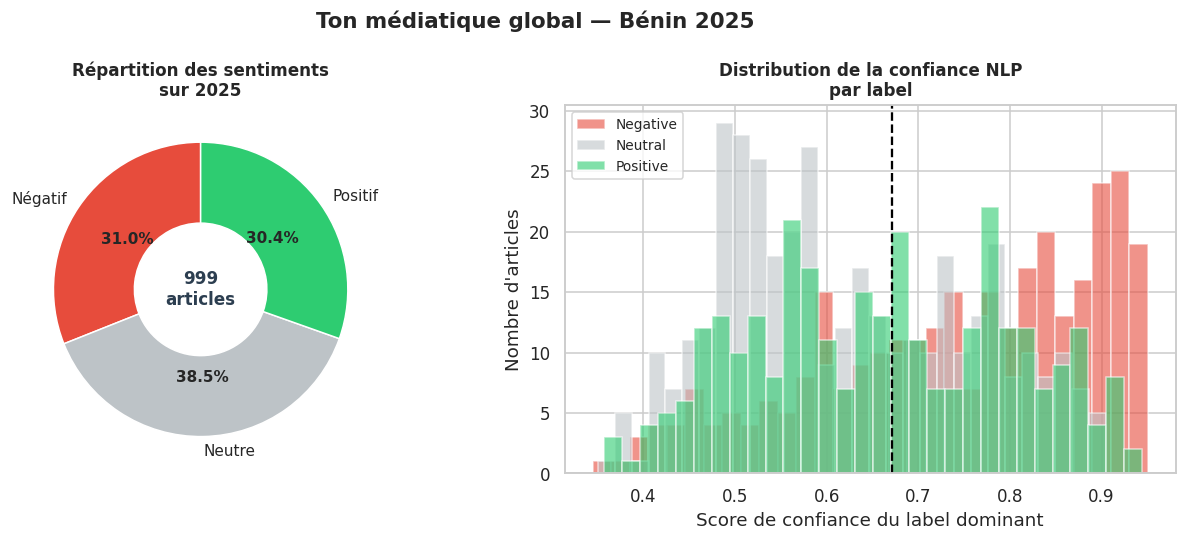

In [61]:
# ── Visualisation globale ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Changed from 1, 3 to 1, 2 subplots

# 1. Donut — répartition des labels
COLORS = {'Negative':'#e74c3c', 'Neutral':'#bdc3c7', 'Positive':'#2ecc71'}
labels_order = ['Negative', 'Neutral', 'Positive']
labels_fr    = ['Négatif', 'Neutre', 'Positif']
sizes  = [n_neg, n_neu, n_pos]
colors = [COLORS[l] for l in labels_order]

wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels_fr, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Répartition des sentiments\nsur 2025',
                   fontsize=11, fontweight='bold')

# Annotation centrale
axes[0].text(0, 0, f"{n_total}\narticles",
             ha='center', va='center', fontsize=11, fontweight='bold', color='#2c3e50')
# Removed: 2. Barres horizontales — scores moyens

# 3. Distribution des scores de confiance par label
for label in labels_order:
    subset = df[df['nlp_label'] == label]['score_top']
    axes[1].hist(subset, bins=30, alpha=0.6, color=COLORS[label],
                 label=label, edgecolor='white') # Re-indexed to axes[1]
axes[1].set_xlabel('Score de confiance du label dominant')
axes[1].set_ylabel("Nombre d'articles")
axes[1].set_title('Distribution de la confiance NLP\npar label',
                   fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].axvline(confiance_moy, color='black', linestyle='--', linewidth=1.5,
                label=f'Moyenne ({confiance_moy:.2f})')

plt.suptitle('Ton médiatique global — Bénin 2025', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig(OUTPUT_DIR / 'nlp_ton_global_2025.png', dpi=150, bbox_inches='tight')
plt.show()


**Ce que le graphique révèle :**

- La part des articles **négatifs** indique si la couverture mondiale du Bénin
  en 2025 est dominée par des événements conflictuels ou problématiques.
- L'**indice de polarité** : une valeur négative confirme
  que la presse internationale parle du Bénin dans un registre plus défavorable
  que favorable sur l'année.
- La **confiance NLP** élevée (> 0.70) indique que les titres des articles sont
  suffisamment expressifs pour que le modèle tranche clairement — les titres
  ambigus sont moins fréquents qu'on pourrait le croire.

## 5. Évolution mensuelle du ton médiatique

On calcule pour chaque mois :
- La **part d'articles négatifs / neutres / positifs**
- L'**indice de polarité mensuel** (`positif − négatif`)

L'indice de polarité est le meilleur résumé : une valeur fortement négative
sur un mois signale une couverture médiatique dégradée, indépendamment
du volume d'articles.

In [62]:
# ── Agrégations mensuelles ────────────────────────────────────────────────────
monthly = (
    df.groupby('month', observed=True)
    .agg(
        n_articles       = ('nlp_label',      'count'),
        n_negative       = ('nlp_label',      lambda x: (x == 'Negative').sum()),
        n_neutral        = ('nlp_label',      lambda x: (x == 'Neutral').sum()),
        n_positive       = ('nlp_label',      lambda x: (x == 'Positive').sum()),
        mean_score_neg   = ('score_negative', 'mean'),
        mean_score_neu   = ('score_neutral',  'mean'),
        mean_score_pos   = ('score_positive', 'mean'),
        mean_confidence  = ('score_top',      'mean'),
    )
    .reset_index()
)

monthly['pct_negative'] = monthly['n_negative'] / monthly['n_articles'] * 100
monthly['pct_neutral']  = monthly['n_neutral']  / monthly['n_articles'] * 100
monthly['pct_positive'] = monthly['n_positive'] / monthly['n_articles'] * 100
monthly['polarite']     = monthly['mean_score_pos'] - monthly['mean_score_neg']
monthly['month_str']    = monthly['month'].astype(str)

# Mois le plus négatif et le plus positif
mois_plus_negatif = monthly.loc[monthly['mean_score_neg'].idxmax(), 'month_str']
mois_plus_positif = monthly.loc[monthly['mean_score_pos'].idxmax(), 'month_str']
mois_plus_polarise = monthly.loc[monthly['polarite'].idxmin(), 'month_str']

print("📅 Tableau mensuel :")
print(f"{'Mois':>10} {'N':>5} {'Négatif':>9} {'Neutre':>8} {'Positif':>9} {'Polarité':>10}")
print("-" * 58)
for _, row in monthly.iterrows():
    flag = " ◄ pic négatif" if row['month_str'] == mois_plus_negatif else ""
    flag = flag or (" ◄ pic positif" if row['month_str'] == mois_plus_positif else "")
    print(f"{row['month_str']:>10} {row['n_articles']:>5.0f} "
          f"{row['pct_negative']:>8.1f}% {row['pct_neutral']:>7.1f}% "
          f"{row['pct_positive']:>8.1f}% {row['polarite']:>+10.3f}{flag}")
print("-" * 58)
print(f"\n🔴 Mois le plus négatif     : {mois_plus_negatif}")
print(f"🟢 Mois le plus positif     : {mois_plus_positif}")
print(f"📉 Polarité la plus basse   : {mois_plus_polarise}")

📅 Tableau mensuel :
      Mois     N   Négatif   Neutre   Positif   Polarité
----------------------------------------------------------
   2025-03   218     33.0%    36.2%     30.7%     -0.051
   2025-04    32     37.5%    25.0%     37.5%     +0.007
   2025-06   250     27.2%    37.2%     35.6%     +0.022
   2025-09   143     37.8%    42.0%     20.3%     -0.157
   2025-10   107     55.1%    34.6%     10.3%     -0.330 ◄ pic négatif
   2025-12   136     22.1%    33.8%     44.1%     +0.151 ◄ pic positif
   2026-01   113     13.3%    54.9%     31.9%     +0.111
----------------------------------------------------------

🔴 Mois le plus négatif     : 2025-10
🟢 Mois le plus positif     : 2025-12
📉 Polarité la plus basse   : 2025-10


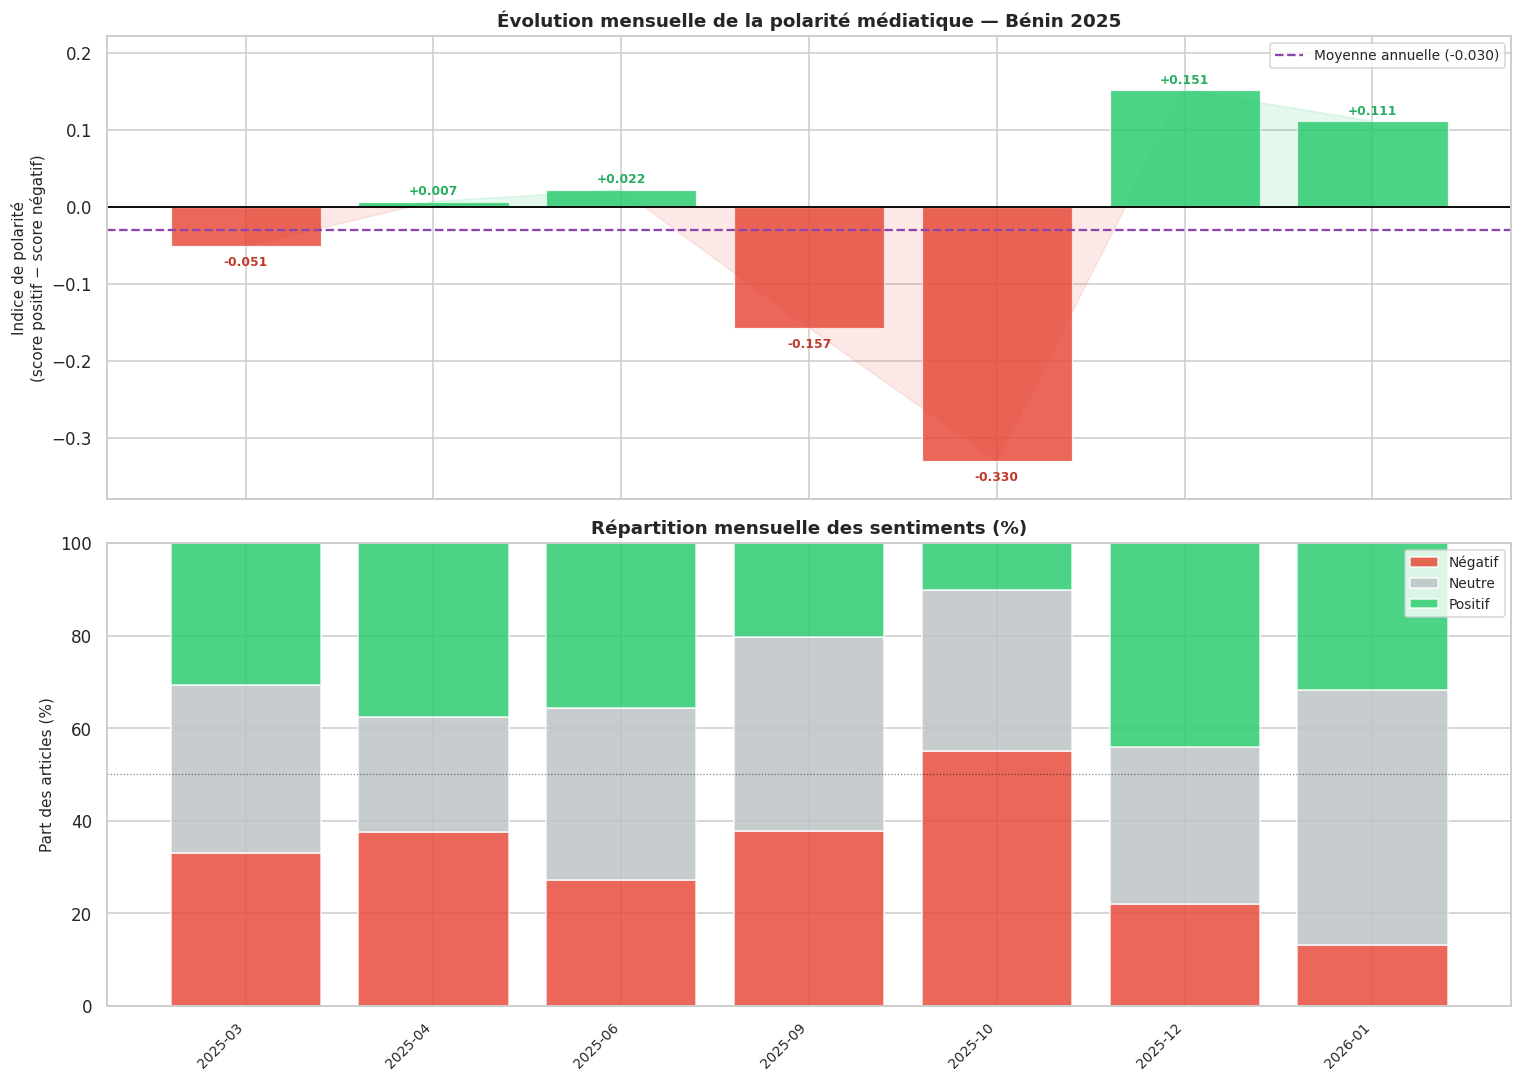

In [63]:
# ── Visualisation 1 : Évolution de l'indice de polarité ──────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

months_x = range(len(monthly))
months_labels = monthly['month_str'].tolist()

# Couleurs des barres selon la polarité
bar_colors_pol = ['#e74c3c' if p < 0 else '#2ecc71' for p in monthly['polarite']]

# ── Graphe 1 : Indice de polarité mensuel ─────────────────────────────────────
bars = axes[0].bar(months_x, monthly['polarite'], color=bar_colors_pol,
                   alpha=0.85, edgecolor='white', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=1.2, linestyle='-')
axes[0].axhline(polarite_annee, color='#8e44ad', linewidth=1.5,
                linestyle='--', label=f'Moyenne annuelle ({polarite_annee:+.3f})')

# Annotations valeurs
for bar, val in zip(bars, monthly['polarite']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + (0.005 if val >= 0 else -0.012),
                 f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top',
                 fontsize=8, fontweight='bold',
                 color='#27ae60' if val >= 0 else '#c0392b')

axes[0].set_ylabel('Indice de polarité\n(score positif − score négatif)', fontsize=10)
axes[0].set_title('Évolution mensuelle de la polarité médiatique — Bénin 2025',
                   fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(monthly['polarite'].min() - 0.05, monthly['polarite'].max() + 0.07)

# Zone colorée pour lire rapidement
axes[0].fill_between(months_x, monthly['polarite'], 0,
                     where=[p < 0 for p in monthly['polarite']],
                     alpha=0.12, color='#e74c3c', interpolate=True)
axes[0].fill_between(months_x, monthly['polarite'], 0,
                     where=[p >= 0 for p in monthly['polarite']],
                     alpha=0.12, color='#2ecc71', interpolate=True)

# ── Graphe 2 : Répartition empilée Négatif / Neutre / Positif ─────────────────
axes[1].bar(months_x, monthly['pct_negative'], color='#e74c3c',
            alpha=0.85, label='Négatif', edgecolor='white')
axes[1].bar(months_x, monthly['pct_neutral'],  color='#bdc3c7',
            alpha=0.85, label='Neutre',  bottom=monthly['pct_negative'], edgecolor='white')
axes[1].bar(months_x, monthly['pct_positive'], color='#2ecc71',
            alpha=0.85, label='Positif',
            bottom=monthly['pct_negative']+monthly['pct_neutral'], edgecolor='white')

axes[1].set_ylabel('Part des articles (%)', fontsize=10)
axes[1].set_title('Répartition mensuelle des sentiments (%)',
                   fontsize=12, fontweight='bold')
axes[1].set_xticks(months_x)
axes[1].set_xticklabels(months_labels, rotation=45, ha='right', fontsize=9)
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=9, loc='upper right')

# Ligne de référence 50%
axes[1].axhline(50, color='black', linewidth=0.8, linestyle=':', alpha=0.5)

plt.tight_layout()
#plt.savefig(OUTPUT_DIR / 'nlp_evolution_mensuelle.png', dpi=150, bbox_inches='tight')
plt.show()

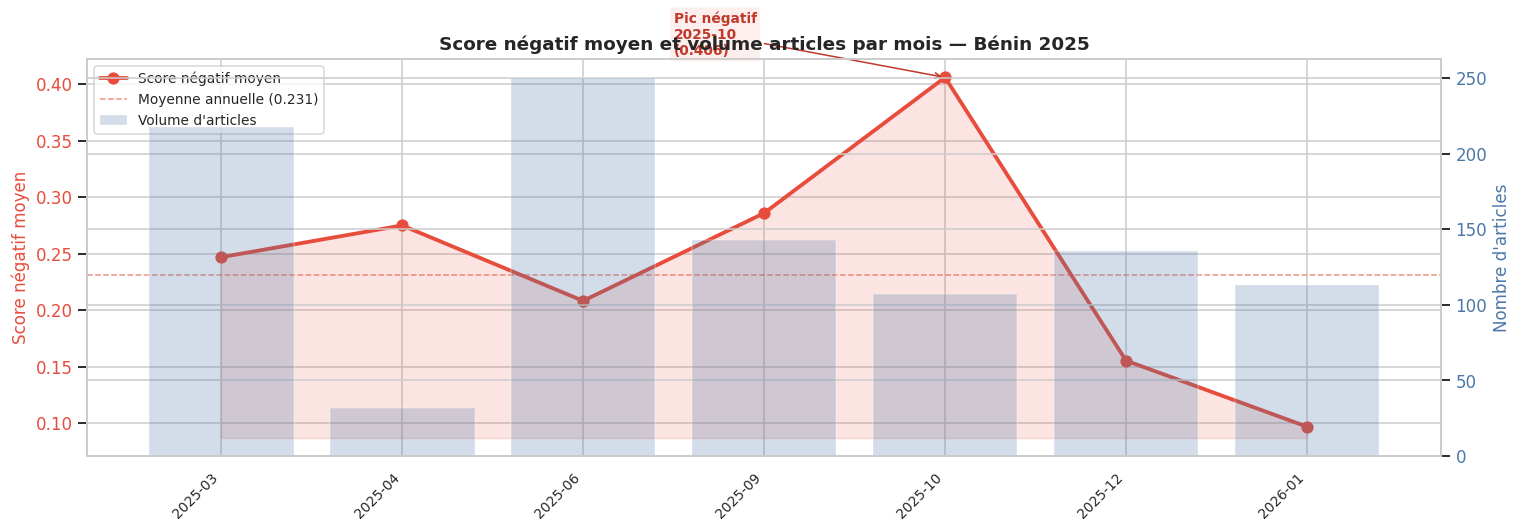

In [64]:
# ── Visualisation 2 : Score négatif moyen + volume ───────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

# Score négatif moyen (ligne)
ax1.plot(months_x, monthly['mean_score_neg'],
         color='#e74c3c', linewidth=2.5, marker='o', markersize=7,
         label='Score négatif moyen', zorder=3)
ax1.fill_between(months_x, monthly['mean_score_neg'],
                 monthly['mean_score_neg'].min() - 0.01,
                 alpha=0.15, color='#e74c3c')
ax1.set_ylabel('Score négatif moyen', fontsize=11, color='#e74c3c')
ax1.tick_params(axis='y', labelcolor='#e74c3c')
ax1.axhline(mean_score_neg, color='#e74c3c', linewidth=1,
            linestyle='--', alpha=0.6, label=f'Moyenne annuelle ({mean_score_neg:.3f})')

# Volume d'articles (barres, axe secondaire)
ax2 = ax1.twinx()
ax2.bar(months_x, monthly['n_articles'], color='#4C78A8', alpha=0.25,
        label="Volume d'articles", zorder=1)
ax2.set_ylabel("Nombre d'articles", fontsize=11, color='#4C78A8')
ax2.tick_params(axis='y', labelcolor='#4C78A8')

ax1.set_xticks(months_x)
ax1.set_xticklabels(months_labels, rotation=45, ha='right', fontsize=9)
ax1.set_title('Score négatif moyen et volume articles par mois — Bénin 2025',
               fontsize=12, fontweight='bold')

# Annotation du pic négatif
idx_pic = monthly['mean_score_neg'].idxmax()
ax1.annotate(
    f"Pic négatif\n{monthly.loc[idx_pic,'month_str']}\n({monthly.loc[idx_pic,'mean_score_neg']:.3f})",
    xy=(idx_pic, monthly.loc[idx_pic,'mean_score_neg']),
    xytext=(idx_pic - 1.5, monthly['mean_score_neg'].max() + 0.02),
    arrowprops=dict(arrowstyle='->', color='#c0392b'),
    fontsize=9, color='#c0392b', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdecea', alpha=0.8)
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')

plt.tight_layout()
#plt.savefig(OUTPUT_DIR / 'nlp_score_negatif_mensuel.png', dpi=150, bbox_inches='tight')
plt.show()

### 💬 Commentaire — Évolution mensuelle

> *Le mois d'Octobre constitue le pic de négativité dans l'actualité béninoise*

> *Le mois avec le score positive le plus élévé sur nos données est Décembre*

**Comment lire les graphiques :**

- **L'indice de polarité** (graphe 1, barres) est le résumé le plus synthétique.
  Un mois en rouge indique que la couverture médiatique est dominée par un registre
  négatif ; en vert, le Bénin est couvert favorablement.
- **La répartition empilée** (graphe 1, bas) montre la structure interne :
  un mois peut avoir peu d'articles mais très polarisés, ou beaucoup d'articles
  avec une répartition équilibrée.
- **Le score négatif moyen** (graphe 2) mesure l'intensité de la négativité
  indépendamment du volume. Un score élevé sur un mois avec peu d'articles
  est plus significatif qu'un score modéré sur un mois avec beaucoup d'articles.


## 6. Sauvegarde des résultats

In [65]:
# ── Sauvegarde du DataFrame enrichi ──────────────────────────────────────────
from pathlib import Path
import pandas as pd # Assurez-vous que pandas est importé pour read_csv

# Définir OUTPUT_DIR pour le stockage local de Colab
OUTPUT_DIR = Path('/content/data') # Créer un dossier spécifique pour les données locales
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Remplacer les scores non nuls par 1 et les scores nuls par 0
for col in ['score_negative', 'score_neutral', 'score_positive']:
    df[col] = (df[col] > 0).astype(int)

# Renommer les colonnes
df = df.rename(columns={
    'score_negative': 'Negative',
    'score_neutral':  'Neutral',
    'score_positive': 'Positive',
    'score_top':      'score_label'
})

output_path = OUTPUT_DIR / 'articles_nlp_benin_2025.csv'
df.to_csv(output_path, index=False)
print(f"✅ Dataset NLP sauvegardé : {output_path}")
print(f"   {len(df)} articles × {len(df.columns)} colonnes")

# Afficher les premières valeurs du CSV sauvegardé
print("\n📝 Premières valeurs du fichier 'articles_nlp_benin_2025.csv' :")
print(pd.read_csv(output_path).head())

# Les opérations de sauvegarde des agrégations mensuelles et de la synthèse ont été supprimées comme demandé.

✅ Dataset NLP sauvegardé : /content/data/articles_nlp_benin_2025.csv
   999 articles × 17 colonnes

📝 Premières valeurs du fichier 'articles_nlp_benin_2025.csv' :
                                                 url  \
0  https://www.financialafrik.com/2025/04/01/la-b...   
1  https://www.fao.org/home/home/benin-s-farmers-...   
2  https://www.maliweb.net/economie/cooperation/l...   
3         https://www.investegate.co.uk/company/PREM   
4  https://lesoleil.sn/actualites/economie/la-boa...   

                                               title          seendate  \
0  ‎La BOAD valide des financements pour 15 proje...  20250401T214500Z   
1  Au Bénin , linnovation est un moteur du dévelo...  20250401T211500Z   
2  maliweb . net - Le Tchad et lAlliance des État...  20250401T184500Z   
3  Premier African Minerals Ltd RNS Announcements...  20250401T174500Z   
4  La Boad valide 15 projets pour 391 , 9 milliar...  20250401T171500Z   

  language              domain   sourcecountry        d

## 7. Synthèse de l'analyse NLP

### Résultats clés


| Indicateur | Valeur | Interprétation |
|------------|--------|----------------|
| Indice de polarité annuel | -0.030 | Ton médiatique plutôt neutre mais proche du négatif |
| Mois le plus négatif | Octobre | L'actualité béninoise de ce mois tend vers des sentiments négatifs|
| Mois le plus positif | Décembre | L'actualité béninoise de ce mois tend vers des sentiments positifs|
| Confiance NLP moyenne | 0.671 | > 0.65 = Assez bon signal quant au résultat du modèle|

